<a href="https://colab.research.google.com/github/salonish03/Data-Analyst-Internship-Projects/blob/main/%20Employee%20Attrition%20Analysis%20and%20Prediction%20Using%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Analysis and Prediction Using Machine Learning

### Data Analytics Internship Project

**Prepared By:** Saloni Sharma

**Organization:** Codec Technologies

---

## Objective

The objective of this project is to analyze employee data and build a machine learning model that predicts whether an employee is likely to leave the organization.

This project helps organizations understand the factors affecting employee attrition and supports better workforce planning.

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1470
Columns : 35


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [10]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


# Data Cleaning Summary

The HR dataset was checked for missing values and duplicate records.

No unnecessary columns were removed at this stage.

The dataset is clean and ready for exploratory data analysis.

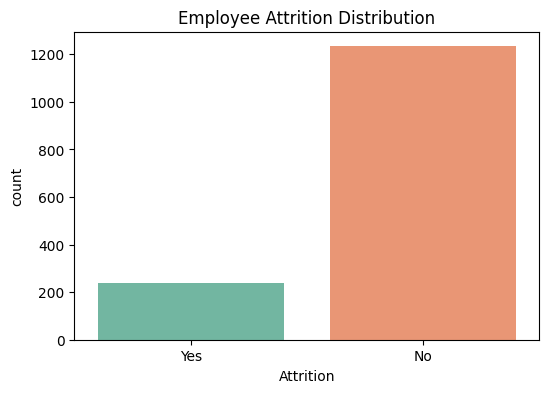

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df,
    palette="Set2"
)

plt.title("Employee Attrition Distribution")

plt.show()

### Observation

Most employees continue working in the organization, while a smaller group leaves the company. This indicates that the dataset is slightly imbalanced.

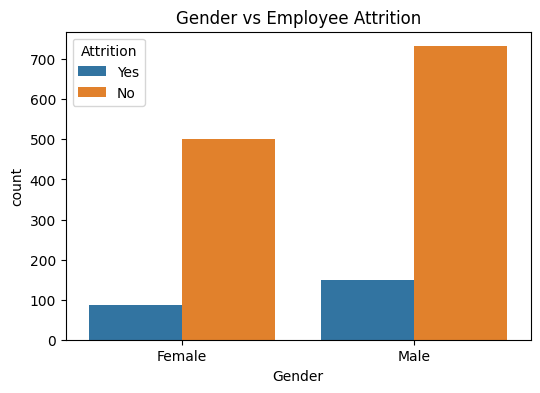

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Attrition",
    data=df
)

plt.title("Gender vs Employee Attrition")

plt.show()

### Observation

Male and female employees show a similar attrition trend, suggesting that gender alone does not strongly influence employee attrition.

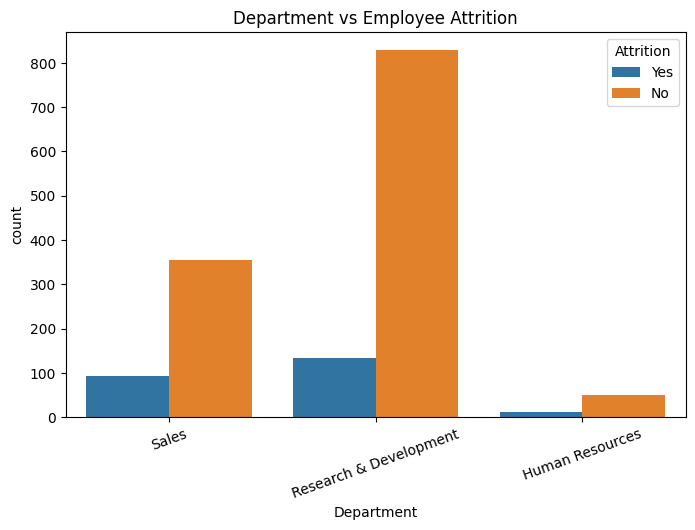

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=20)

plt.title("Department vs Employee Attrition")

plt.show()

### Observation

Attrition differs across departments, indicating that the work environment and department-specific factors may influence employee turnover.

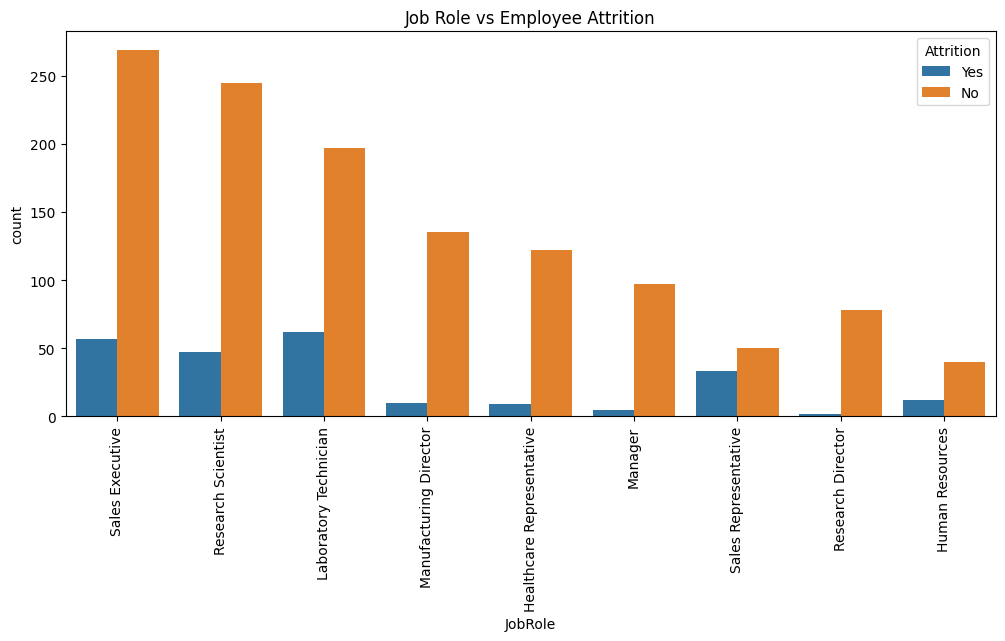

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="JobRole",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=90)

plt.title("Job Role vs Employee Attrition")

plt.show()

### Observation

Certain job roles experience higher employee attrition than others, highlighting the importance of job-specific retention strategies.

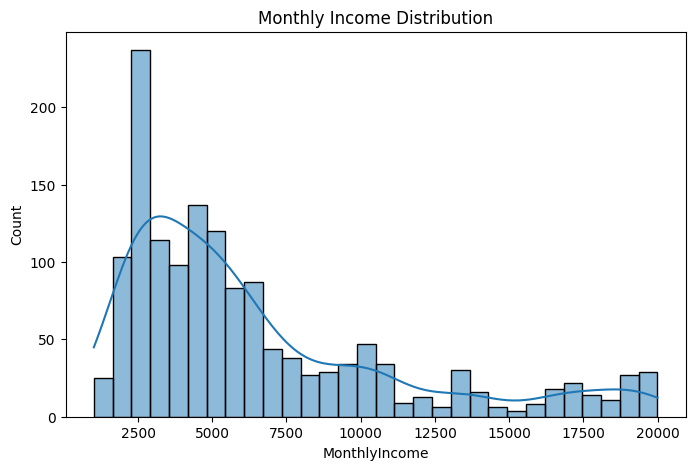

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyIncome"],
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")

plt.show()

### Observation

Most employees earn a moderate monthly income, while only a small number fall into the highest salary range.

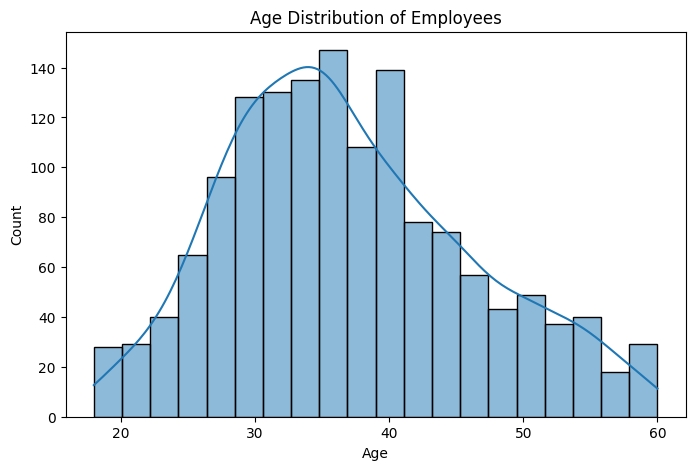

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution of Employees")

plt.show()

### Observation

Most employees belong to the age group of approximately 30 to 40 years.

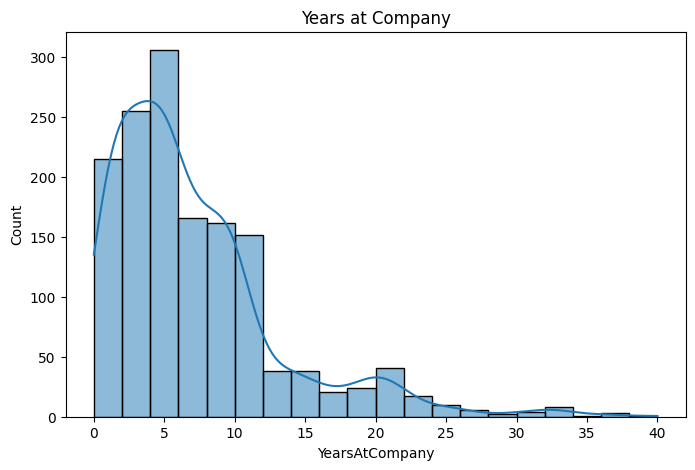

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["YearsAtCompany"],
    bins=20,
    kde=True
)

plt.title("Years at Company")

plt.show()

### Observation

Many employees have worked for only a few years, while fewer employees have very long service periods.

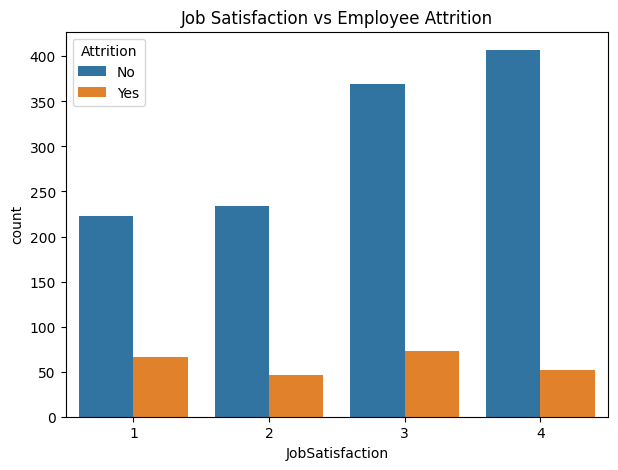

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="JobSatisfaction",
    hue="Attrition",
    data=df
)

plt.title("Job Satisfaction vs Employee Attrition")

plt.show()

### Observation

Employees with lower job satisfaction tend to leave the organization more frequently than employees with higher job satisfaction.

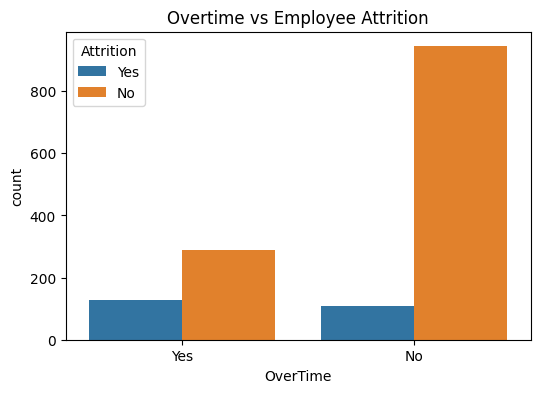

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df
)

plt.title("Overtime vs Employee Attrition")

plt.show()

### Observation

Employees who frequently work overtime show a higher tendency to leave the company.

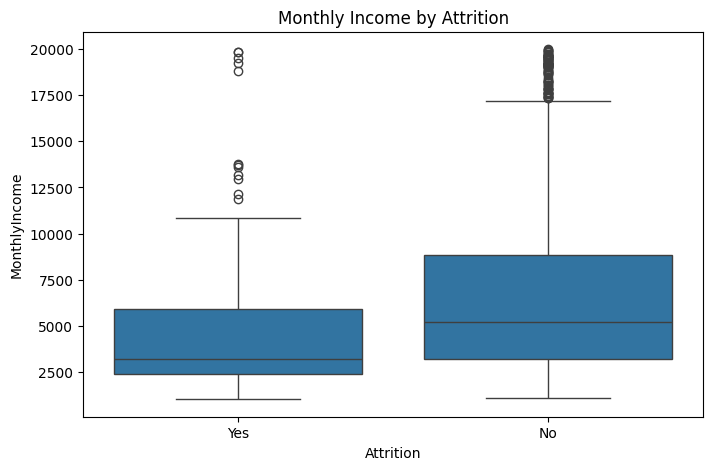

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income by Attrition")

plt.show()

### Observation

Salary levels differ between employees who stay and those who leave, although income alone is not the only factor affecting attrition.

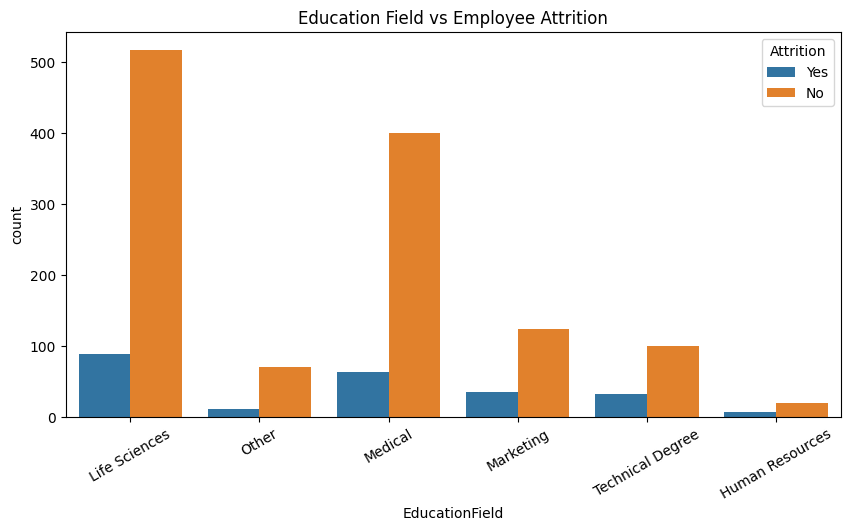

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="EducationField",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=30)

plt.title("Education Field vs Employee Attrition")

plt.show()

### Observation

Attrition patterns vary across different education fields, suggesting that educational background may influence career movement.

# EDA Summary

The visual analysis highlights several important findings:

- Employees working overtime are more likely to leave.
- Job satisfaction appears to influence attrition.
- Attrition varies across departments and job roles.
- Employees with fewer years at the company tend to leave more often.
- Monthly income may contribute to attrition, but it is not the only deciding factor.

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


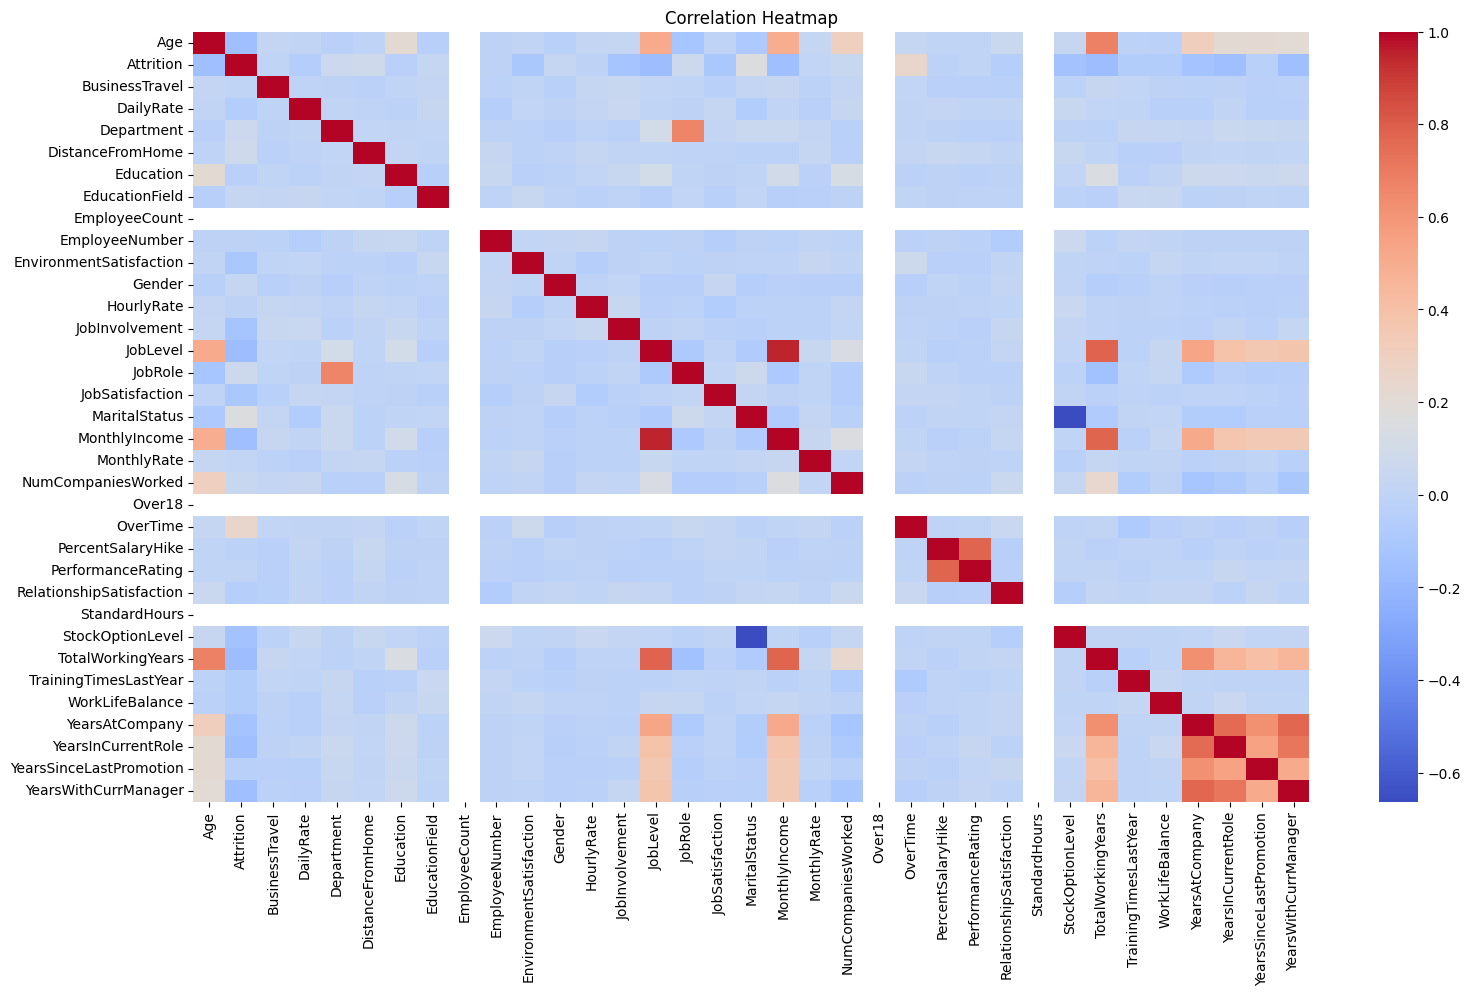

In [23]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap helps identify relationships among different employee attributes. Features such as OverTime, MonthlyIncome, YearsAtCompany, and JobSatisfaction show noticeable relationships with employee attrition.

In [24]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
y_pred_lr = log_model.predict(X_test)

In [29]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.891156462585034


In [30]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



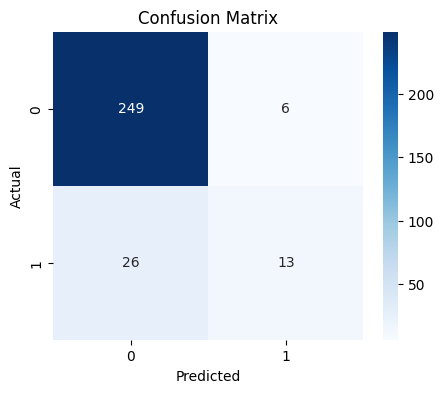

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [32]:
y_probability = log_model.predict_proba(X_test)[:,1]

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, y_probability)
)

ROC-AUC Score: 0.7721468074409251


# Logistic Regression Summary

The Logistic Regression model was trained and evaluated using multiple performance metrics.

The model provides a baseline for predicting employee attrition and helps compare performance with more advanced models in the next section.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
y_pred_rf = rf_model.predict(X_test)

In [35]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8639455782312925


In [36]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.44      0.10      0.17        39

    accuracy                           0.86       294
   macro avg       0.66      0.54      0.55       294
weighted avg       0.82      0.86      0.83       294



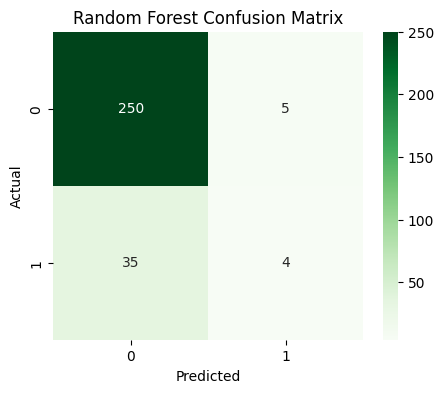

In [37]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [38]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(
    "Random Forest ROC-AUC Score:",
    roc_auc_score(y_test, y_prob_rf)
)

Random Forest ROC-AUC Score: 0.7064353946706888


In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
17,MonthlyIncome,0.074968
21,OverTime,0.064823
0,Age,0.056865
2,DailyRate,0.050505
27,TotalWorkingYears,0.048104
18,MonthlyRate,0.047090
8,EmployeeNumber,0.045296
11,HourlyRate,0.043352
4,DistanceFromHome,0.042012
30,YearsAtCompany,0.041914


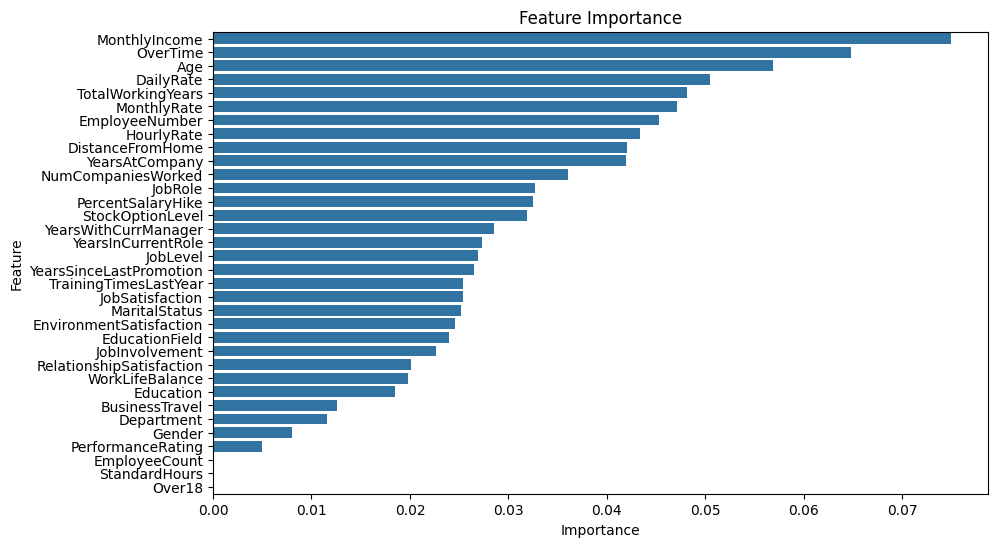

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [41]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.891156
1,Random Forest,0.863946


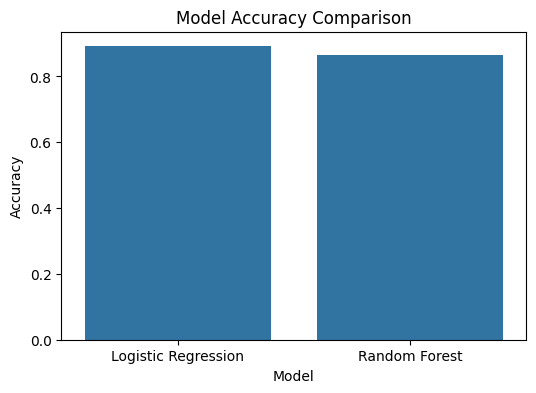

In [42]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [43]:
sample_employee = X_test[0].reshape(1, -1)

prediction = rf_model.predict(sample_employee)

if prediction[0] == 1:
    print("Prediction: Employee is likely to leave the company.")
else:
    print("Prediction: Employee is likely to stay with the company.")

Prediction: Employee is likely to stay with the company.


In [44]:
import pickle

with open("employee_attrition_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully.")

Model saved successfully.


In [45]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully.")

Scaler saved successfully.


In [46]:
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Label Encoder saved successfully.")

Label Encoder saved successfully.
